In [10]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# ── pick one song per mood to visualize ─────────────────
df = pd.read_csv('../data/features.csv')
MOOD_MAP = {'Happy':'pop','Sad':'blues','Angry':'metal','Relaxed':'classical'}

def get_sample_path(genre):
    folder = os.path.join('..','data','raw','Data','genres_original', genre)
    files  = [f for f in os.listdir(folder) if f.endswith('.wav')]
    return os.path.join(folder, files[0])

print("Sample files:")
for mood, genre in MOOD_MAP.items():
    print(f"  {mood} ({genre}): {get_sample_path(genre)}")

Sample files:
  Happy (pop): ..\data\raw\Data\genres_original\pop\pop.00000.wav
  Sad (blues): ..\data\raw\Data\genres_original\blues\blues.00000.wav
  Angry (metal): ..\data\raw\Data\genres_original\metal\metal.00000.wav
  Relaxed (classical): ..\data\raw\Data\genres_original\classical\classical.00000.wav


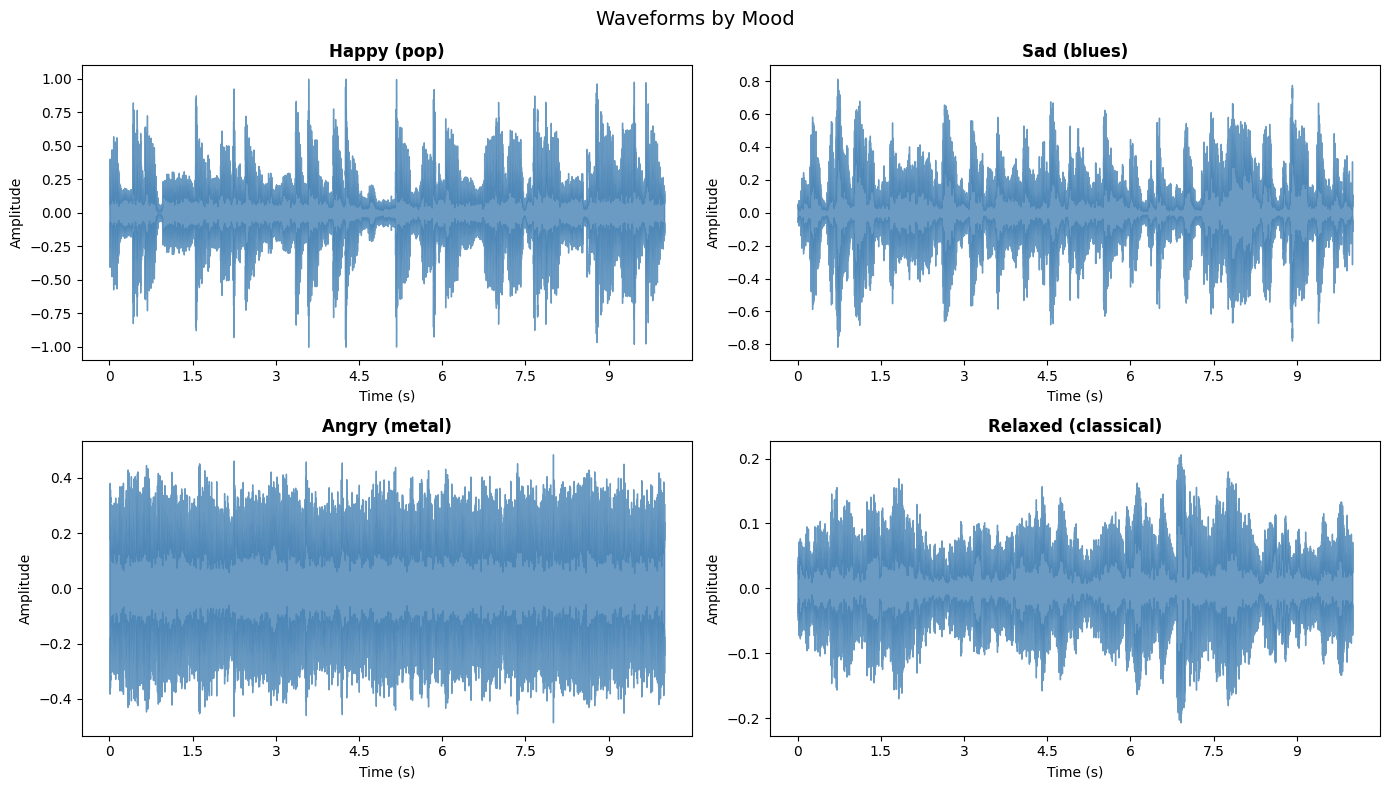

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (mood, genre) in zip(axes.flat, MOOD_MAP.items()):
    path = get_sample_path(genre)
    y, sr = librosa.load(path, duration=10, mono=True)
    librosa.display.waveshow(y, sr=sr, ax=ax, color='steelblue', alpha=0.8)
    ax.set_title(f'{mood} ({genre})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

plt.suptitle('Waveforms by Mood', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/feat_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()

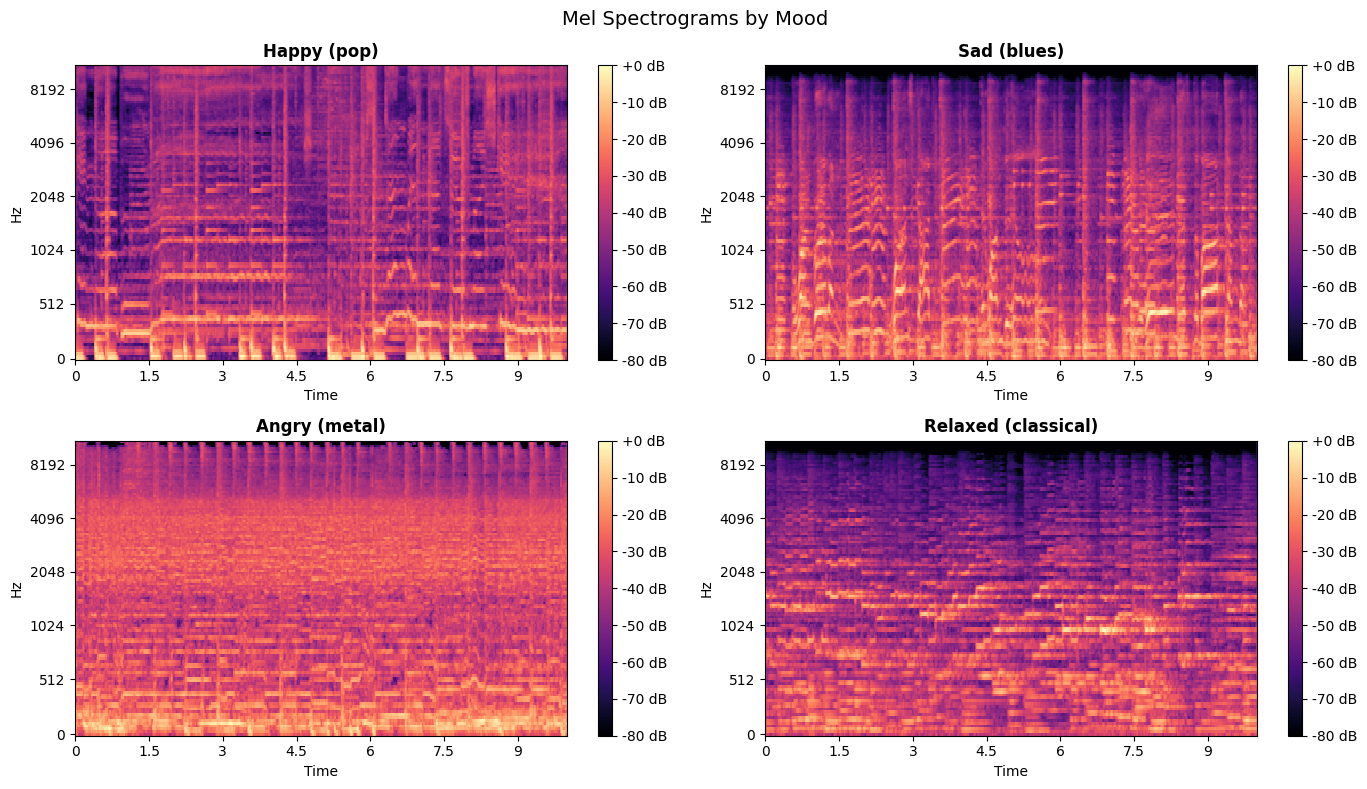

Notice: metal (Angry) is brighter/noisier, classical (Relaxed) is darker/smoother


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (mood, genre) in zip(axes.flat, MOOD_MAP.items()):
    path = get_sample_path(genre)
    y, sr = librosa.load(path, duration=10, mono=True)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time',
                                    y_axis='mel', ax=ax, cmap='magma')
    ax.set_title(f'{mood} ({genre})', fontsize=12, fontweight='bold')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.suptitle('Mel Spectrograms by Mood', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/feat_melspectrograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Notice: metal (Angry) is brighter/noisier, classical (Relaxed) is darker/smoother")

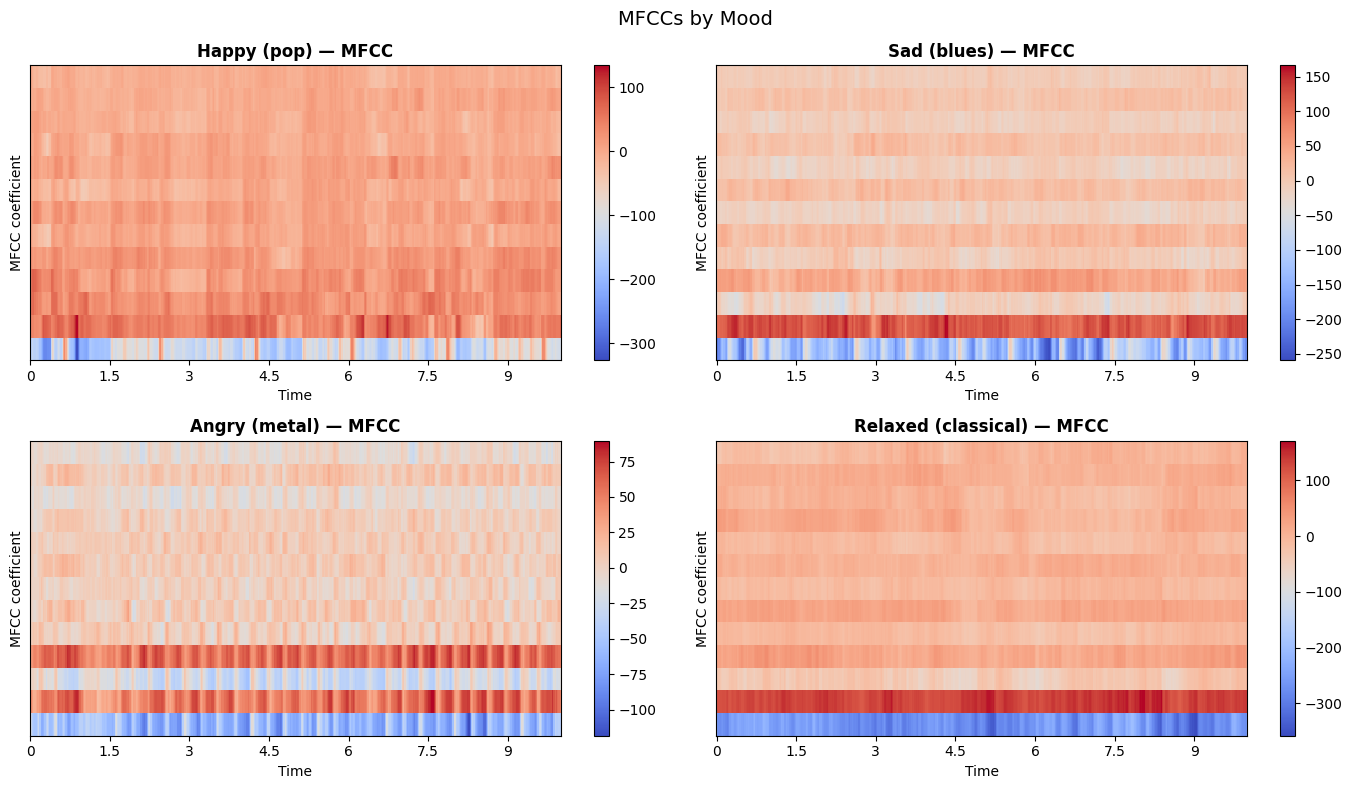

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (mood, genre) in zip(axes.flat, MOOD_MAP.items()):
    path = get_sample_path(genre)
    y, sr = librosa.load(path, duration=10, mono=True)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    img = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=ax, cmap='coolwarm')
    ax.set_title(f'{mood} ({genre}) — MFCC', fontsize=12, fontweight='bold')
    ax.set_ylabel('MFCC coefficient')
    fig.colorbar(img, ax=ax)

plt.suptitle('MFCCs by Mood', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/feat_mfccs.png', dpi=150, bbox_inches='tight')
plt.show()

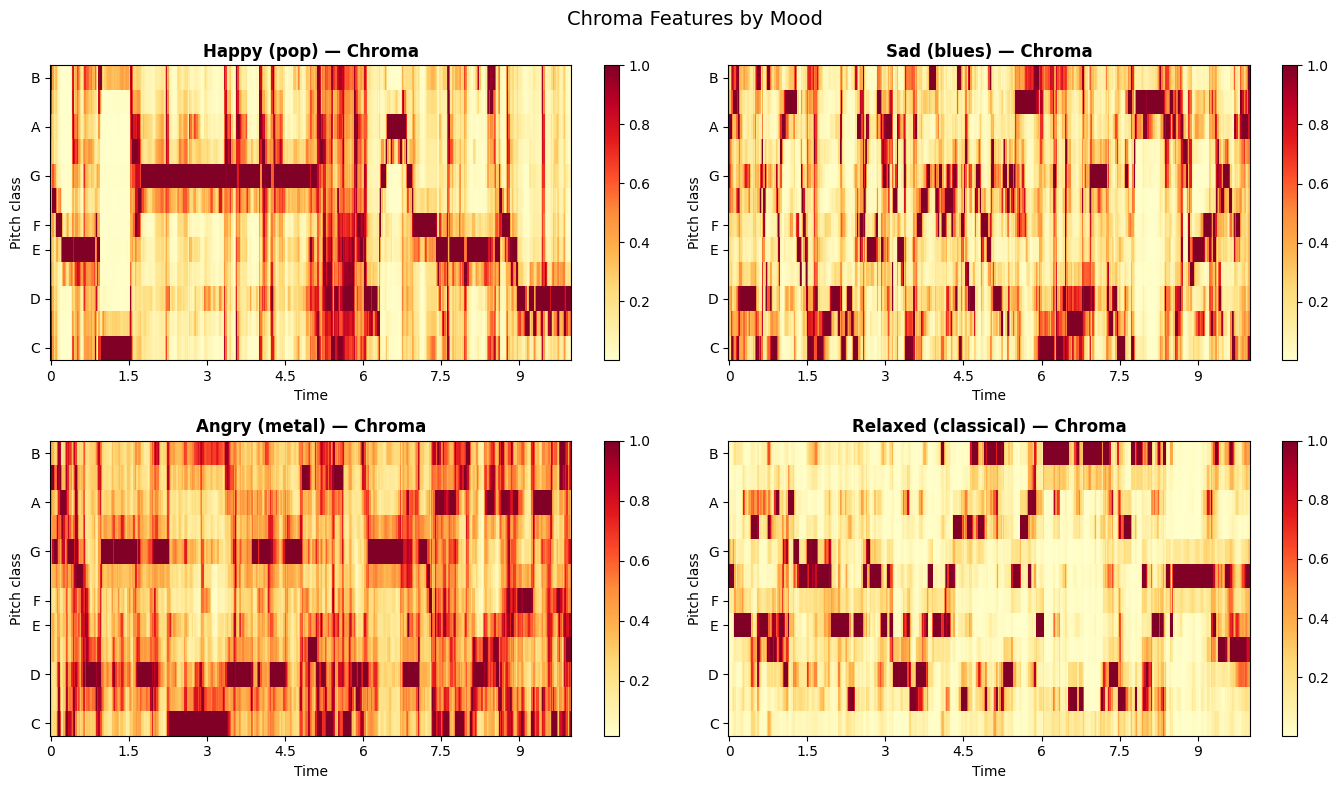

Major key (happy): energy concentrated in specific chroma bins
Minor key (sad):   different distribution pattern


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (mood, genre) in zip(axes.flat, MOOD_MAP.items()):
    path = get_sample_path(genre)
    y, sr = librosa.load(path, duration=10, mono=True)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    img = librosa.display.specshow(chroma, sr=sr, x_axis='time',
                                    y_axis='chroma', ax=ax, cmap='YlOrRd')
    ax.set_title(f'{mood} ({genre}) — Chroma', fontsize=12, fontweight='bold')
    fig.colorbar(img, ax=ax)

plt.suptitle('Chroma Features by Mood', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/feat_chroma.png', dpi=150, bbox_inches='tight')
plt.show()
print("Major key (happy): energy concentrated in specific chroma bins")
print("Minor key (sad):   different distribution pattern")

In [15]:
df = pd.read_csv('../data/features.csv')
meta = ['filename','genre','mood']
feat_cols = [c for c in df.columns if c not in meta]

summary = df.groupby('mood')[feat_cols].mean()
print("Mean feature values per mood class:")
print(summary[['tempo','rms_mean','zcr_mean','centroid_mean',
               'mfcc_mean_0','mfcc_mean_1']].round(3).to_string())

Mean feature values per mood class:
             tempo  rms_mean  zcr_mean  centroid_mean  mfcc_mean_0  mfcc_mean_1
mood                                                                           
Angry      124.874     0.153     0.148       2602.220      -63.086       85.926
Energetic  116.704     0.153     0.109       2383.687     -106.722       90.032
Happy      120.822     0.153     0.118       2626.336     -108.062       82.148
Relaxed    120.726     0.064     0.077       1572.828     -268.071      127.861
Sad        115.820     0.131     0.081       1811.929     -154.838      113.715
